# Pre-2020 walk-forward HAR × sentiment robustness

**Status:** retrospective historical robustness, specification frozen on
2026-08-05 before Notebook 25 execution. Notebook 24's direct product was
proposed after the 2020-2023 evaluation block had been opened; this notebook
asks whether the same unchanged composition also works in earlier years when
every HAR fit uses only targets already complete at its refit date.

## Frozen design

- **Data:** FNSPID aggregate pressure and SPY adjusted-open returns through
  2019-12-31 only.
- **HAR base:** sentiment-free Notebook 21 features and 10% annual target,
  exposure [0.25, 1.00]. Start after 504 chronological rows, refit an
  expanding model every 21 sessions, and admit training targets only when
  `target_end_date < refit_date`.
- **Sentiment:** exact Notebook 20 development hysteresis exposure (entry
  z >= 1.5, exit z <= 0.5, multiplier 0.25). No refit or threshold change.
- **Costs/inference:** 2 bps per side; 0/1/2/5/10-bps curve; paired
  20-session circular blocks with 4,999 replications.
- **Stability:** 2013-2015 versus 2016-2019.

The Notebook 24 gates are repeated as diagnostics. Passing them here would be
corroboration across older dates, not fresh confirmation, because the product
itself was proposed after later evaluation results were known.

In [1]:
from __future__ import annotations

import hashlib
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.plots import (  # noqa: E402
    CATEGORICAL,
    INK,
    STATUS,
    apply_house_style,
)
from final_experiments.lib.risk_overlay import (  # noqa: E402
    MomentumOverlayConfig,
    reprice_daily,
    summarize_weight_backtest,
)
from final_experiments.lib.volatility_target import (  # noqa: E402
    CONTROL_FEATURES,
    VolatilityTargetConfig,
    backtest_single_asset_exposure,
    build_volatility_frame,
    build_volatility_target_exposure,
    multiply_exposures,
    paired_circular_block_mean,
    qlike_loss,
    walk_forward_variance_forecast,
)

apply_house_style()
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

OUTPUT_DIR = REPO_ROOT / "final_experiments" / "outputs" / "25_fnspid_har_sentiment_walkforward"
BASELINE_PATH = (
    REPO_ROOT
    / "final_experiments"
    / "outputs"
    / "20_fnspid_market_sentiment_risk_overlay"
    / "development_baseline_daily.parquet"
)
PRESSURE_PATH = (
    REPO_ROOT
    / "final_experiments"
    / "outputs"
    / "20_fnspid_market_sentiment_risk_overlay"
    / "daily_aggregate_pressure.parquet"
)
SENTIMENT_PATH = (
    REPO_ROOT
    / "final_experiments"
    / "outputs"
    / "20_fnspid_market_sentiment_risk_overlay"
    / "development_hysteresis_daily.parquet"
)
INITIAL_TRAINING_ROWS = 504
REFIT_EVERY = 21
COST_BPS = 2.0
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)
BLOCK_LENGTH = 20
REPLICATIONS = 4_999
SEED = 20260805
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"repo:   {REPO_ROOT}")
print(f"output: {OUTPUT_DIR}")

repo:   /Users/peterprendergast/Documents/Sentiment_Dissertation
output: /Users/peterprendergast/Documents/Sentiment_Dissertation/final_experiments/outputs/25_fnspid_har_sentiment_walkforward


## Load the frozen development components

In [2]:
for required_path in (BASELINE_PATH, PRESSURE_PATH, SENTIMENT_PATH):
    if not required_path.exists():
        raise FileNotFoundError(required_path)

baseline = pd.read_parquet(BASELINE_PATH)
pressure = pd.read_parquet(PRESSURE_PATH)
sentiment_source = pd.read_parquet(SENTIMENT_PATH)
for frame in (baseline, pressure, sentiment_source):
    frame["session_date"] = pd.to_datetime(frame["session_date"]).dt.normalize()

def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

input_audit = pd.DataFrame(
    [
        {
            "development_return_rows": len(baseline),
            "development_start": baseline["session_date"].min(),
            "development_end": baseline["session_date"].max(),
            "pressure_rows": len(pressure),
            "sentiment_rows": len(sentiment_source),
            "initial_training_rows": INITIAL_TRAINING_ROWS,
            "refit_every": REFIT_EVERY,
            "baseline_sha256": sha256(BASELINE_PATH),
            "pressure_sha256": sha256(PRESSURE_PATH),
            "sentiment_sha256": sha256(SENTIMENT_PATH),
        }
    ]
)
display(input_audit)

,development_return_rows,development_start,development_end,pressure_rows,sentiment_rows,initial_training_rows,refit_every,baseline_sha256,pressure_sha256,sentiment_sha256
0,2263,2011-01-03,2019-12-30,3262,2263,504,21,8562e7db63301b3b9a3014944056ef11662192f5e4f854...,405076d864cbecb4c0667a190f282ea95323dda6b5531f...,d4c2e875894bfac42111ec7c31496f5fd7c2357b3e55fd...


## Build causal features and expanding walk-forward forecasts

In [3]:
config = VolatilityTargetConfig(
    target_annual_volatility=0.10,
    minimum_exposure=0.25,
    maximum_exposure=1.00,
    cost_bps_per_side=COST_BPS,
    bootstrap_block_length=BLOCK_LENGTH,
    bootstrap_replications=REPLICATIONS,
    random_seed=SEED,
)
returns = baseline[["session_date", "gross_return"]].copy()
frame = build_volatility_frame(returns, pressure, config=config, return_col="gross_return")
forecasts, fit_audit = walk_forward_variance_forecast(
    frame,
    CONTROL_FEATURES,
    initial_training_rows=INITIAL_TRAINING_ROWS,
    refit_every=REFIT_EVERY,
)
if not (fit_audit["maximum_training_target_end"] < fit_audit["refit_date"]).all():
    raise RuntimeError("walk-forward training target crosses a refit boundary")

forecast_audit = forecasts.merge(
    frame[["session_date", "realized_variance_forward"]],
    on="session_date",
    how="left",
    validate="1:1",
).dropna(subset=["forecast_variance", "realized_variance_forward"])
forecast_metrics = pd.DataFrame(
    [
        {
            "n_complete_targets": len(forecast_audit),
            "mean_qlike": qlike_loss(
                forecast_audit["realized_variance_forward"].to_numpy(),
                forecast_audit["forecast_variance"].to_numpy(),
            ).mean(),
            "forecast_actual_spearman": forecast_audit[
                ["forecast_variance", "realized_variance_forward"]
            ].corr(method="spearman").iloc[0, 1],
            "n_refits": len(fit_audit),
            "first_forecast_session": forecasts["session_date"].min(),
            "last_forecast_session": forecasts["session_date"].max(),
            "minimum_training_rows": fit_audit["n_train"].min(),
            "maximum_training_rows": fit_audit["n_train"].max(),
        }
    ]
)
display(forecast_metrics)
display(fit_audit.head())

,n_complete_targets,mean_qlike,forecast_actual_spearman,n_refits,first_forecast_session,last_forecast_session,minimum_training_rows,maximum_training_rows
0,1755,-8.783936,0.494645,84,2013-01-04,2019-12-30,478,2221


,fit_number,refit_date,forecast_start,forecast_end,n_forecast_rows,n_train,maximum_training_target_end,qlike_scale,log_var_daily,log_var_weekly,log_var_monthly
0,1,2013-01-04,2013-01-04,2013-02-04,21,478,2013-01-03,1.308209,0.018977,0.161927,0.582285
1,2,2013-02-05,2013-02-05,2013-03-06,21,499,2013-02-04,1.353069,0.036688,0.214162,0.494893
2,3,2013-03-07,2013-03-07,2013-04-05,21,520,2013-03-06,1.372954,0.035341,0.257920,0.416552
3,4,2013-04-08,2013-04-08,2013-05-06,21,541,2013-04-05,1.381575,0.035129,0.265384,0.428427
4,5,2013-05-07,2013-05-07,2013-06-05,21,562,2013-05-06,1.378928,0.029124,0.257384,0.439949


## Compose the unchanged sentiment modifier and backtest

In [4]:
forecast_frame = forecasts.merge(
    frame[["session_date", "forward_return"]],
    on="session_date",
    how="left",
    validate="1:1",
)
base_exposure = build_volatility_target_exposure(
    forecast_frame,
    forecast_frame["forecast_variance"],
    config=config,
    arm="walkforward_har",
)
sentiment_modifier = sentiment_source[["session_date", "gross_exposure"]].rename(
    columns={"gross_exposure": "exposure"}
)
sentiment_modifier = base_exposure[["session_date"]].merge(
    sentiment_modifier,
    on="session_date",
    how="left",
    validate="1:1",
)
if sentiment_modifier["exposure"].isna().any():
    raise RuntimeError("sentiment state does not cover walk-forward sessions")
overlay_exposure = multiply_exposures(
    base_exposure,
    sentiment_modifier,
    arm="walkforward_har_sentiment",
)
returns_walkforward = forecast_frame[["session_date", "forward_return"]]
exposures = {
    "walkforward_har": base_exposure,
    "walkforward_har_sentiment": overlay_exposure,
}

summary_config = MomentumOverlayConfig(
    cost_bps_per_side=COST_BPS,
    bootstrap_block_length=BLOCK_LENGTH,
    bootstrap_replications=REPLICATIONS,
    random_seed=SEED,
)
daily_paths: dict[str, pd.DataFrame] = {}
result_rows = []
for arm, exposure in exposures.items():
    daily = backtest_single_asset_exposure(
        returns_walkforward,
        exposure[["session_date", "exposure"]],
        cost_bps_per_side=COST_BPS,
    )
    daily["arm"] = arm
    daily["downside_sq"] = daily["net_return"].clip(upper=0).pow(2)
    daily_paths[arm] = daily
    result_rows.append({"arm": arm, **summarize_weight_backtest(daily, config=summary_config)})
results = pd.DataFrame(result_rows)
display(
    results[
        [
            "arm",
            "n_sessions",
            "sharpe_gross",
            "sharpe_net",
            "total_return_net",
            "ann_vol_net",
            "max_drawdown",
            "mean_gross_exposure",
            "annualized_turnover",
            "breakeven_bps_per_side",
        ]
    ]
)

,arm,n_sessions,sharpe_gross,sharpe_net,total_return_net,ann_vol_net,max_drawdown,mean_gross_exposure,annualized_turnover,breakeven_bps_per_side
0,walkforward_har,1759,1.136350,1.113905,0.969064,0.090871,-0.125291,0.815479,5.085782,101.514426
1,walkforward_har_sentiment,1759,1.215290,1.163947,0.931349,0.084070,-0.085706,0.756500,10.762333,47.460672


## Paired inference, stability, and costs

In [5]:
base = daily_paths["walkforward_har"].set_index("session_date")
overlay = daily_paths["walkforward_har_sentiment"].set_index("session_date")
common = base.index.intersection(overlay.index).sort_values()
net_difference = overlay.loc[common, "net_return"] - base.loc[common, "net_return"]
downside_improvement = base.loc[common, "downside_sq"] - overlay.loc[common, "downside_sq"]
net_inference = paired_circular_block_mean(
    net_difference,
    block_length=BLOCK_LENGTH,
    replications=REPLICATIONS,
    seed=SEED + 1,
)
downside_inference = paired_circular_block_mean(
    downside_improvement,
    block_length=BLOCK_LENGTH,
    replications=REPLICATIONS,
    seed=SEED + 2,
)
paired_inference = pd.DataFrame(
    [
        {"estimand": "walk-forward HAR sentiment minus HAR net return", **net_inference},
        {"estimand": "HAR minus sentiment downside squared return", **downside_inference},
    ]
)
display(paired_inference)

def period_summary(arm: str, label: str, start: str, end: str) -> dict[str, float | int | str]:
    daily = daily_paths[arm]
    subset = daily.loc[daily["session_date"].between(pd.Timestamp(start), pd.Timestamp(end))]
    summary = summarize_weight_backtest(subset, config=summary_config)
    return {
        "period": label,
        "arm": arm,
        "n_sessions": summary["n_sessions"],
        "mean_net": summary["mean_net"],
        "sharpe_net": summary["sharpe_net"],
        "total_return_net": summary["total_return_net"],
        "max_drawdown": summary["max_drawdown"],
    }

periods = (
    ("2013_2015", "2013-01-01", "2015-12-31"),
    ("2016_2019", "2016-01-01", "2019-12-31"),
)
temporal = pd.DataFrame(
    [period_summary(arm, label, start, end) for label, start, end in periods for arm in exposures]
)
stability_rows = []
for label, _, _ in periods:
    part = temporal.loc[temporal["period"].eq(label)].set_index("arm")
    stability_rows.append(
        {
            "period": label,
            "overlay_minus_base_bps_day": 10_000
            * (
                part.loc["walkforward_har_sentiment", "mean_net"]
                - part.loc["walkforward_har", "mean_net"]
            ),
            "overlay_minus_base_sharpe": part.loc[
                "walkforward_har_sentiment", "sharpe_net"
            ]
            - part.loc["walkforward_har", "sharpe_net"],
        }
    )
stability = pd.DataFrame(stability_rows)
display(temporal)
display(stability)

cost_rows = []
for arm, daily in daily_paths.items():
    for cost in COST_GRID:
        repriced = reprice_daily(daily, cost_bps_per_side=cost)
        cost_config = MomentumOverlayConfig(
            cost_bps_per_side=cost,
            bootstrap_block_length=BLOCK_LENGTH,
            bootstrap_replications=999,
            random_seed=SEED,
        )
        summary = summarize_weight_backtest(repriced, config=cost_config)
        cost_rows.append(
            {
                "arm": arm,
                "cost_bps_per_side": cost,
                "sharpe_net": summary["sharpe_net"],
                "total_return_net": summary["total_return_net"],
                "max_drawdown": summary["max_drawdown"],
            }
        )
cost_curve = pd.DataFrame(cost_rows)
display(cost_curve)

,estimand,n,mean,ci_low,ci_high,p_two_sided,block_length,replications,seed
0,walk-forward HAR sentiment minus HAR net return,1759,-0.000013,-0.000099,0.000074,0.763200,20,4999,20260806
1,HAR minus sentiment downside squared return,1759,0.000003,0.000001,0.000005,0.005200,20,4999,20260807


,period,arm,n_sessions,mean_net,sharpe_net,total_return_net,max_drawdown
0,2013_2015,walkforward_har,754,0.000383,1.002573,0.316726,-0.095223
1,2013_2015,walkforward_har_sentiment,754,0.000387,1.069905,0.321990,-0.085706
2,2016_2019,walkforward_har,1005,0.000415,1.209212,0.495425,-0.125291
3,2016_2019,walkforward_har_sentiment,1005,0.000389,1.251284,0.460941,-0.080253


,period,overlay_minus_base_bps_day,overlay_minus_base_sharpe
0,2013_2015,0.033276,0.067333
1,2016_2019,-0.258967,0.042073


,arm,cost_bps_per_side,sharpe_net,total_return_net,max_drawdown
0,walkforward_har,0.000000,1.136350,0.997220,-0.124817
1,walkforward_har,1.000000,1.125128,0.983092,-0.125054
2,walkforward_har,2.000000,1.113905,0.969064,-0.125291
3,walkforward_har,5.000000,1.080233,0.927572,-0.126002
4,walkforward_har,10.000000,1.024103,0.860350,-0.127185
5,walkforward_har_sentiment,0.000000,1.215290,0.990254,-0.084767
6,walkforward_har_sentiment,1.000000,1.189623,0.960580,-0.085237
7,walkforward_har_sentiment,2.000000,1.163947,0.931349,-0.085706
8,walkforward_har_sentiment,5.000000,1.086876,0.846236,-0.087322
9,walkforward_har_sentiment,10.000000,0.958324,0.712613,-0.094568


## Repeat the frozen direct-product diagnostic gates

In [6]:
result_index = results.set_index("arm")
sharpe_delta = float(
    result_index.loc["walkforward_har_sentiment", "sharpe_net"]
    - result_index.loc["walkforward_har", "sharpe_net"]
)
drawdown_improvement = float(
    1
    - abs(result_index.loc["walkforward_har_sentiment", "max_drawdown"])
    / abs(result_index.loc["walkforward_har", "max_drawdown"])
)
gates = {
    "net_sharpe_improvement": sharpe_delta,
    "drawdown_relative_improvement": drawdown_improvement,
    "paired_net_mean_bps_day": 10_000 * float(net_inference["mean"]),
    "paired_net_ci_low_bps_day": 10_000 * float(net_inference["ci_low"]),
    "paired_net_ci_high_bps_day": 10_000 * float(net_inference["ci_high"]),
    "downside_improvement_mean": float(downside_inference["mean"]),
    "downside_improvement_p_two_sided": float(downside_inference["p_two_sided"]),
    "stable_nonnegative_mean_both_periods": bool(stability["overlay_minus_base_bps_day"].ge(0).all()),
    "alpha_gate": bool(
        float(net_inference["ci_low"]) > 0
        and float(result_index.loc["walkforward_har_sentiment", "bootstrap_net_ci_low"]) > 0
        and sharpe_delta >= 0.10
    ),
    "useful_risk_gate": bool(
        sharpe_delta >= 0.10
        and drawdown_improvement >= 0.20
        and 10_000 * float(net_inference["ci_low"]) >= -1.0
        and float(downside_inference["mean"]) > 0
        and float(downside_inference["p_two_sided"]) < 0.05
    ),
}
display(pd.DataFrame([gates]))

,net_sharpe_improvement,drawdown_relative_improvement,paired_net_mean_bps_day,paired_net_ci_low_bps_day,paired_net_ci_high_bps_day,downside_improvement_mean,downside_improvement_p_two_sided,stable_nonnegative_mean_both_periods,alpha_gate,useful_risk_gate
0,0.050042,0.315945,-0.133696,-0.987482,0.736419,0.000003,0.005200,False,False,False


## Figures

findfont: Failed to find font weight medium, now using 400.


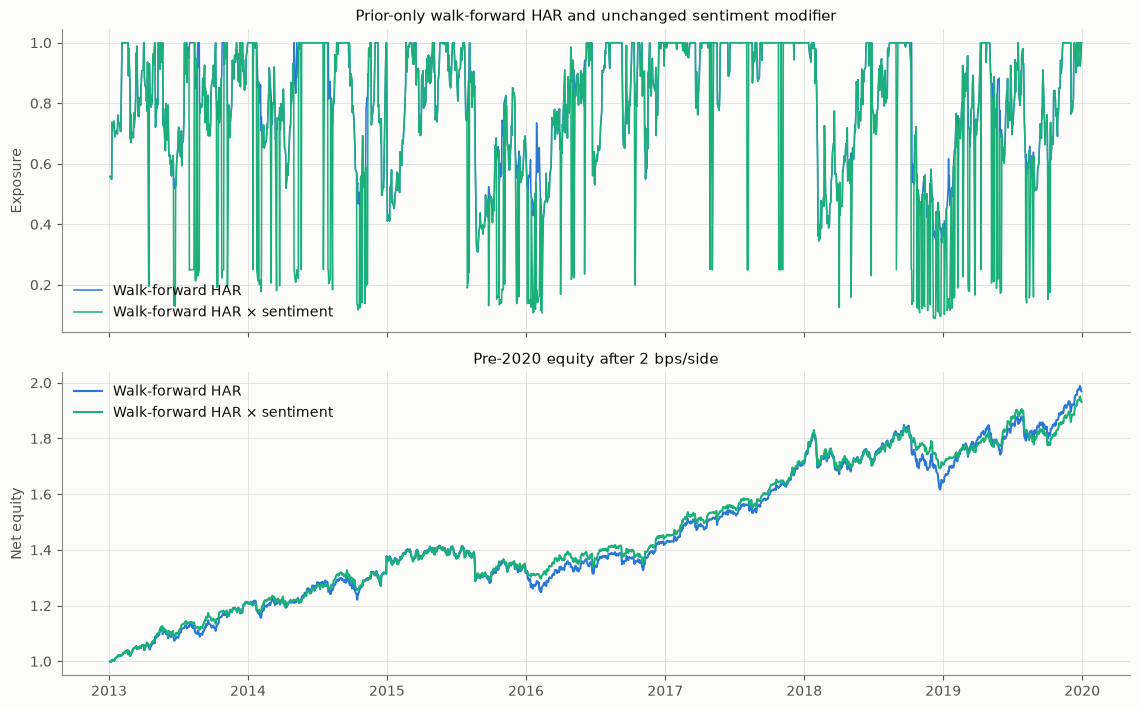

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11.5, 7.2), sharex=True)
for arm, label, color in (
    ("walkforward_har", "Walk-forward HAR", CATEGORICAL[0]),
    ("walkforward_har_sentiment", "Walk-forward HAR × sentiment", CATEGORICAL[2]),
):
    daily = daily_paths[arm]
    axes[0].plot(daily["session_date"], daily["gross_exposure"], label=label, color=color, linewidth=1.1)
    axes[1].plot(
        daily["session_date"],
        (1 + daily["net_return"]).cumprod(),
        label=label,
        color=color,
        linewidth=1.5,
    )
axes[0].set_ylabel("Exposure")
axes[0].set_title("Prior-only walk-forward HAR and unchanged sentiment modifier")
axes[0].legend(loc="best")
axes[1].set_ylabel("Net equity")
axes[1].set_title("Pre-2020 equity after 2 bps/side")
axes[1].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "exposure_and_equity.png", dpi=170, bbox_inches="tight")
plt.show()

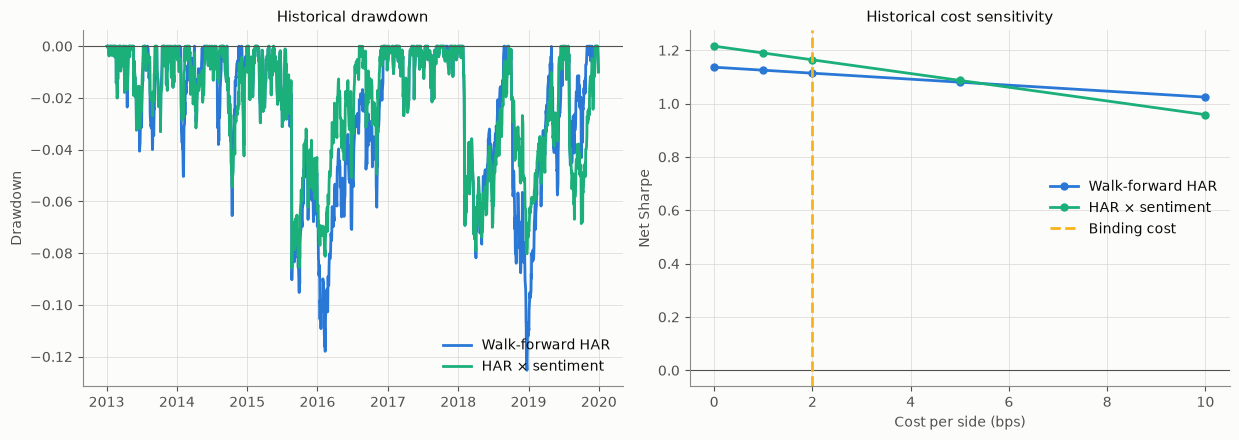

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
for arm, label, color in (
    ("walkforward_har", "Walk-forward HAR", CATEGORICAL[0]),
    ("walkforward_har_sentiment", "HAR × sentiment", CATEGORICAL[2]),
):
    daily = daily_paths[arm]
    equity = (1 + daily["net_return"]).cumprod()
    drawdown = equity / equity.cummax() - 1
    axes[0].plot(daily["session_date"], drawdown, label=label, color=color)
    group = cost_curve.loc[cost_curve["arm"].eq(arm)]
    axes[1].plot(group["cost_bps_per_side"], group["sharpe_net"], marker="o", label=label, color=color)
axes[0].axhline(0, color=INK["reference"], linewidth=0.8)
axes[0].set_ylabel("Drawdown")
axes[0].set_title("Historical drawdown")
axes[0].legend(loc="lower right")
axes[1].axhline(0, color=INK["reference"], linewidth=0.8)
axes[1].axvline(COST_BPS, color=STATUS["warning"], linestyle="--", label="Binding cost")
axes[1].set_xlabel("Cost per side (bps)")
axes[1].set_ylabel("Net Sharpe")
axes[1].set_title("Historical cost sensitivity")
axes[1].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "drawdown_and_cost.png", dpi=170, bbox_inches="tight")
plt.show()

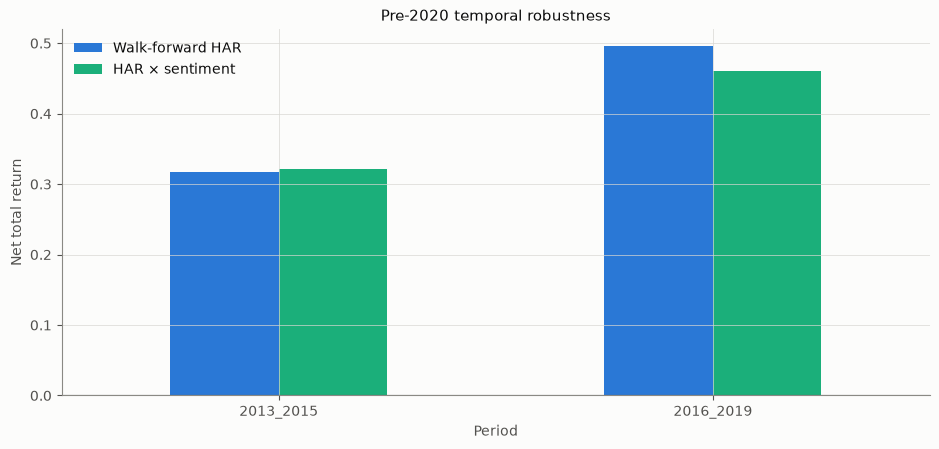

In [9]:
temporal_plot = temporal.pivot(index="period", columns="arm", values="total_return_net").rename(
    columns={
        "walkforward_har": "Walk-forward HAR",
        "walkforward_har_sentiment": "HAR × sentiment",
    }
)
ax = temporal_plot.plot(
    kind="bar",
    figsize=(9.5, 4.6),
    color=[CATEGORICAL[0], CATEGORICAL[2]],
)
ax.axhline(0, color=INK["reference"], linewidth=0.8)
ax.set_xlabel("Period")
ax.set_ylabel("Net total return")
ax.set_title("Pre-2020 temporal robustness")
ax.legend(loc="best")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "temporal_returns.png", dpi=170, bbox_inches="tight")
plt.show()

## Persist aggregate evidence and decide

In [10]:
input_audit.to_csv(OUTPUT_DIR / "input_audit.csv", index=False)
forecast_metrics.to_csv(OUTPUT_DIR / "forecast_metrics.csv", index=False)
fit_audit.to_csv(OUTPUT_DIR / "fit_audit.csv", index=False)
forecasts.to_parquet(OUTPUT_DIR / "walkforward_forecasts.parquet", index=False)
results.to_csv(OUTPUT_DIR / "results.csv", index=False)
paired_inference.to_csv(OUTPUT_DIR / "paired_inference.csv", index=False)
temporal.to_csv(OUTPUT_DIR / "temporal_results.csv", index=False)
stability.to_csv(OUTPUT_DIR / "temporal_stability.csv", index=False)
cost_curve.to_csv(OUTPUT_DIR / "cost_curve.csv", index=False)
pd.DataFrame([gates]).to_csv(OUTPUT_DIR / "gates.csv", index=False)
for arm, daily in daily_paths.items():
    daily.to_parquet(OUTPUT_DIR / f"{arm}_daily.parquet", index=False)

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None

manifest = {
    "notebook": "25_fnspid_har_sentiment_walkforward",
    "built_for": "pre-2020 prior-only robustness of the exact HAR and aggregate-hysteresis product",
    "analysis_status": "retrospective_historical_robustness_frozen_before_notebook25_execution_2026-08-05",
    "git_commit_at_execution": git_commit,
    "design": {
        "initial_training_rows": INITIAL_TRAINING_ROWS,
        "refit_every_sessions": REFIT_EVERY,
        "training_rule": "target_end_date strictly before refit_date",
        "base": "sentiment-free HAR 10% volatility target",
        "sentiment_rule": {"entry_z": 1.5, "exit_z": 0.5, "risk_exposure_multiplier": 0.25},
        "cost_bps_per_side": COST_BPS,
        "cost_grid": list(COST_GRID),
        "bootstrap": {
            "kind": "paired circular block",
            "block_length": BLOCK_LENGTH,
            "replications": REPLICATIONS,
            "seed": SEED,
        },
    },
    "forecast_metrics": json.loads(
        forecast_metrics.to_json(orient="records", date_format="iso")
    )[0],
    "results": json.loads(results.to_json(orient="records")),
    "paired_inference": json.loads(paired_inference.to_json(orient="records")),
    "temporal_stability": json.loads(stability.to_json(orient="records")),
    "gates": gates,
    "limitations": [
        "the direct product was proposed after 2020-2023 evaluation results were known",
        "this is a retrospective walk-forward audit, not a registered confirmation",
        "the earliest 504 development rows are used only to initialise fitting",
        "the expanding model is refit every 21 sessions rather than every day",
        "SPY adjusted-open returns omit dividends and cash earns zero",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2, allow_nan=True) + "\n")

alpha_verdict = "passes" if gates["alpha_gate"] else "does not pass"
risk_verdict = "passes" if gates["useful_risk_gate"] else "does not pass"
display(
    Markdown(
        f"""### Decision

On prior-only pre-2020 fits, the exact HAR × sentiment product **{alpha_verdict}**
the repeated alpha gate and **{risk_verdict}** the repeated useful-risk gate.

- Walk-forward HAR net/gross Sharpes:
  **{result_index.loc['walkforward_har', 'sharpe_net']:.3f} /
  {result_index.loc['walkforward_har', 'sharpe_gross']:.3f}**.
- HAR × sentiment net/gross Sharpes:
  **{result_index.loc['walkforward_har_sentiment', 'sharpe_net']:.3f} /
  {result_index.loc['walkforward_har_sentiment', 'sharpe_gross']:.3f}**.
- Paired net difference: **{10_000 * float(net_inference['mean']):.3f} bp/day**
  (95% block interval **[{10_000 * float(net_inference['ci_low']):.3f},
  {10_000 * float(net_inference['ci_high']):.3f}]**).
- Relative maximum-drawdown improvement: **{drawdown_improvement:.1%}**.

This result is used only to judge whether Notebook 24's 2020-driven pattern
has older temporal support. It cannot promote the strategy by itself.
"""
    )
)

### Decision

On prior-only pre-2020 fits, the exact HAR × sentiment product **does not pass**
the repeated alpha gate and **does not pass** the repeated useful-risk gate.

- Walk-forward HAR net/gross Sharpes:
  **1.114 /
  1.136**.
- HAR × sentiment net/gross Sharpes:
  **1.164 /
  1.215**.
- Paired net difference: **-0.134 bp/day**
  (95% block interval **[-0.987,
  0.736]**).
- Relative maximum-drawdown improvement: **31.6%**.

This result is used only to judge whether Notebook 24's 2020-driven pattern
has older temporal support. It cannot promote the strategy by itself.


## Next-step rule

If the older walk-forward path fails or changes sign, describe the direct
product as crisis-period concentration and stop. If it corroborates the same
risk mechanism, freeze the exact product for genuinely new post-2023 data;
do not use these older dates to tune the thresholds or the HAR target.